In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Load data
df = pd.read_csv('/content/Crimes_-_2001_to_Present_20251023.csv')

# Drop rows without coordinates
df = df.dropna(subset=['Latitude', 'Longitude'])

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
    crs="EPSG:4326"
)

gdf.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1352325 entries, 0 to 1371844
Data columns (total 23 columns):
 #   Column                Non-Null Count    Dtype   
---  ------                --------------    -----   
 0   ID                    1352325 non-null  int64   
 1   Case Number           1352325 non-null  object  
 2   Date                  1352325 non-null  object  
 3   Block                 1352325 non-null  object  
 4   IUCR                  1352325 non-null  object  
 5   Primary Type          1352325 non-null  object  
 6   Description           1352325 non-null  object  
 7   Location Description  1346680 non-null  object  
 8   Arrest                1352325 non-null  bool    
 9   Domestic              1352325 non-null  bool    
 10  Beat                  1352325 non-null  int64   
 11  District              1352325 non-null  int64   
 12  Ward                  1352292 non-null  float64 
 13  Community Area        1352229 non-null  float64 
 14  FBI Code       

In [3]:
import geopandas as gpd

# Replace path with your downloaded file
communities = gpd.read_file("/content/Boundaries_-_Community_Areas_20251023.geojson")


In [4]:
# Ensure both have same CRS
gdf = gdf.set_crs("EPSG:4326")
communities = communities.to_crs("EPSG:4326")

# Spatial join
gdf_joined = gpd.sjoin(gdf, communities, how="inner", predicate="within")

gdf_joined.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1348011 entries, 0 to 1371844
Data columns (total 33 columns):
 #   Column                Non-Null Count    Dtype              
---  ------                --------------    -----              
 0   ID                    1348011 non-null  int64              
 1   Case Number           1348011 non-null  object             
 2   Date                  1348011 non-null  object             
 3   Block                 1348011 non-null  object             
 4   IUCR                  1348011 non-null  object             
 5   Primary Type          1348011 non-null  object             
 6   Description           1348011 non-null  object             
 7   Location Description  1342375 non-null  object             
 8   Arrest                1348011 non-null  bool               
 9   Domestic              1348011 non-null  bool               
 10  Beat                  1348011 non-null  int64              
 11  District              1348011 non-

In [5]:
crime_counts = (
    gdf_joined.groupby('community')
    .size()
    .reset_index(name='crime_count')
)


In [6]:
merged = communities.merge(crime_counts, on='community', how='left')
merged['crime_count'] = merged['crime_count'].fillna(0)


In [7]:
merged = merged.copy()

# Convert datetime columns to string
for col in merged.select_dtypes(include=['datetime64[ms, UTC]']).columns:
    merged[col] = merged[col].astype(str)


In [8]:
merged.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   :id          77 non-null     object  
 1   :version     77 non-null     object  
 2   :created_at  77 non-null     object  
 3   :updated_at  77 non-null     object  
 4   area_numbe   77 non-null     object  
 5   community    77 non-null     object  
 6   area_num_1   77 non-null     object  
 7   shape_area   77 non-null     object  
 8   shape_len    77 non-null     object  
 9   geometry     77 non-null     geometry
 10  crime_count  77 non-null     int64   
dtypes: geometry(1), int64(1), object(9)
memory usage: 6.7+ KB


In [9]:
import folium

m = folium.Map(location=[41.8781, -87.6298], zoom_start=10, tiles='cartodbpositron')

# Add choropleth layer
folium.Choropleth(
    geo_data=merged,
    data=merged,
    columns=['community', 'crime_count'],
    key_on='feature.properties.community',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='Crimes per Community Area'
).add_to(m)

# Add labels (optional)
folium.GeoJsonTooltip(
    fields=['community', 'crime_count'],
    aliases=['Community Area:', 'Crime Count:'],
    sticky=True
).add_to(folium.GeoJson(merged).add_to(m))

m


In [ ]:
top_crimes = (
    gdf_joined['Primary Type']
    .value_counts()
    .nlargest(5)
    .index
)



THEFT top 5:
          community  Crime Count
0  NEAR NORTH SIDE        21787
1             LOOP        16857
2   NEAR WEST SIDE        16266
3        WEST TOWN        13062
4        LAKE VIEW        12341


/tmp/ipython-input-2739208779.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


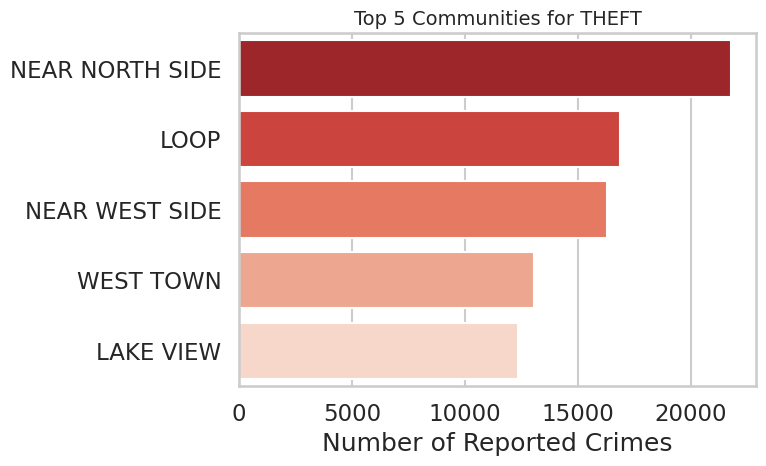


BATTERY top 5:
          community  Crime Count
0           AUSTIN        15488
1      SOUTH SHORE        10426
2   NORTH LAWNDALE         8969
3  NEAR NORTH SIDE         7904
4   AUBURN GRESHAM         7776


/tmp/ipython-input-2739208779.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


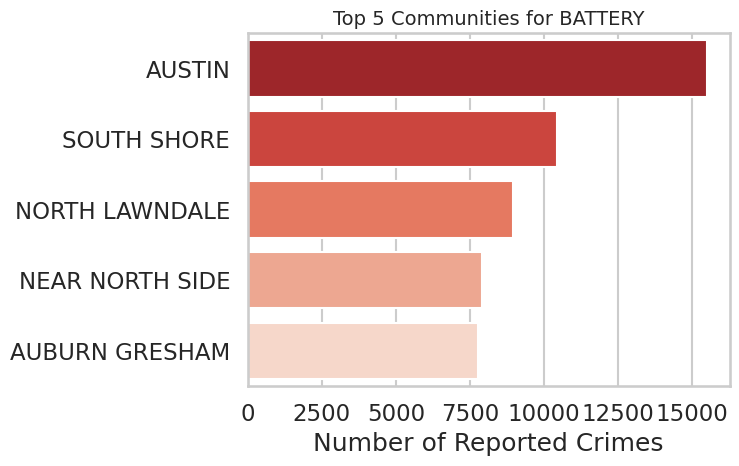


CRIMINAL DAMAGE top 5:
         community  Crime Count
0          AUSTIN         8106
1     SOUTH SHORE         6208
2  NEAR WEST SIDE         5540
3  AUBURN GRESHAM         5095
4        ROSELAND         4778


/tmp/ipython-input-2739208779.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


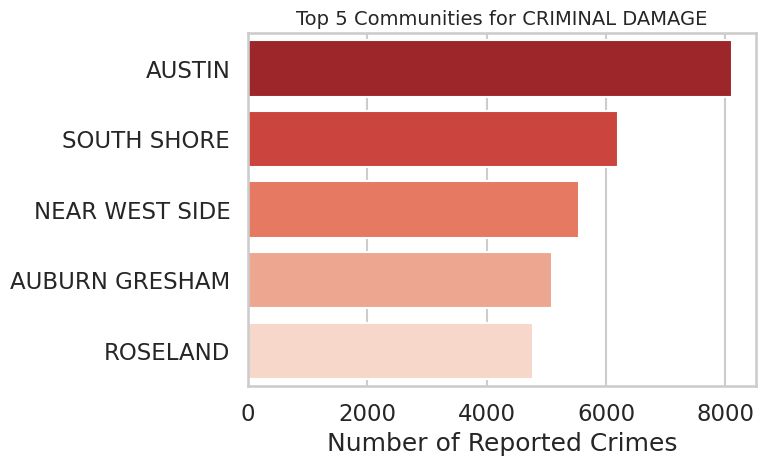


ASSAULT top 5:
                 community  Crime Count
0                  AUSTIN         6992
1             SOUTH SHORE         5218
2          NEAR WEST SIDE         4130
3          AUBURN GRESHAM         4048
4  GREATER GRAND CROSSING         3849


/tmp/ipython-input-2739208779.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


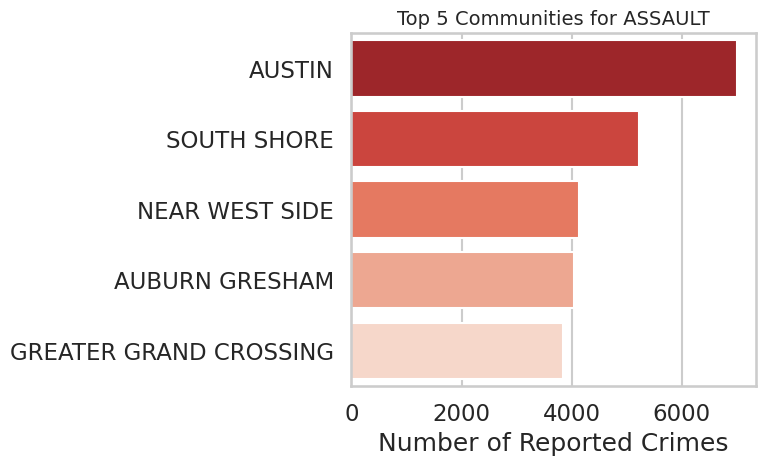


MOTOR VEHICLE THEFT top 5:
                 community  Crime Count
0                  AUSTIN         5574
1          NEAR WEST SIDE         4386
2             SOUTH SHORE         4163
3               WEST TOWN         3965
4  GREATER GRAND CROSSING         3179


/tmp/ipython-input-2739208779.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


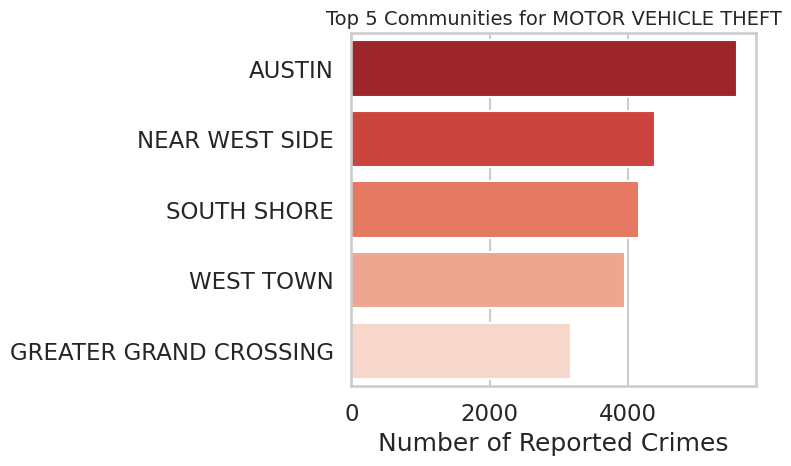

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

for crime in top_crimes:
    sub = gdf_joined[gdf_joined["Primary Type"] == crime]

    # Count crimes per community and take top 5
    top_areas = (
        sub["community"]
        .value_counts()
        .head(5)
        .reset_index()
        .rename(columns={"index": "community", "count": "Crime Count"})
    )

    # Check
    print(f"\n{crime} top 5:\n", top_areas)

    # Plot
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=top_areas,
        x="Crime Count",
        y="community",  # <-- use lowercase 'community'
        palette="Reds_r"
    )
    plt.title(f"Top 5 Communities for {crime}", fontsize=14)
    plt.xlabel("Number of Reported Crimes")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(gdf['Community Area'], gdf['Primary Type'])
chi2, p, dof, ex = chi2_contingency(table)
print(f"Chi²={chi2:.2f}, p={p:.3f}")


Chi²=207862.75, p=0.000



=== Cluster Size Summary ===
cluster
0    11
1     3
2    22
3    31
4    10
Name: count, dtype: int64

=== Top Crime Types per Cluster ===

Cluster 0:
  • THEFT                     6932.91
  • BATTERY                   4565.73
  • CRIMINAL DAMAGE           2923.00
  • ASSAULT                   2156.45
  • MOTOR VEHICLE THEFT       1972.73

Cluster 1:
  • THEFT                     16114.33
  • BATTERY                   10299.00
  • CRIMINAL DAMAGE           5757.33
  • ASSAULT                   4852.67
  • DECEPTIVE PRACTICE        4454.33

Cluster 2:
  • THEFT                     3558.86
  • BATTERY                   2700.86
  • CRIMINAL DAMAGE           1787.55
  • ASSAULT                   1376.05
  • MOTOR VEHICLE THEFT       1269.23

Cluster 3:
  • THEFT                     1320.35
  • BATTERY                   1003.26
  • CRIMINAL DAMAGE           735.87
  • DECEPTIVE PRACTICE        550.26
  • ASSAULT                   540.35

Cluster 4:
  • BATTERY                   7426.40
  

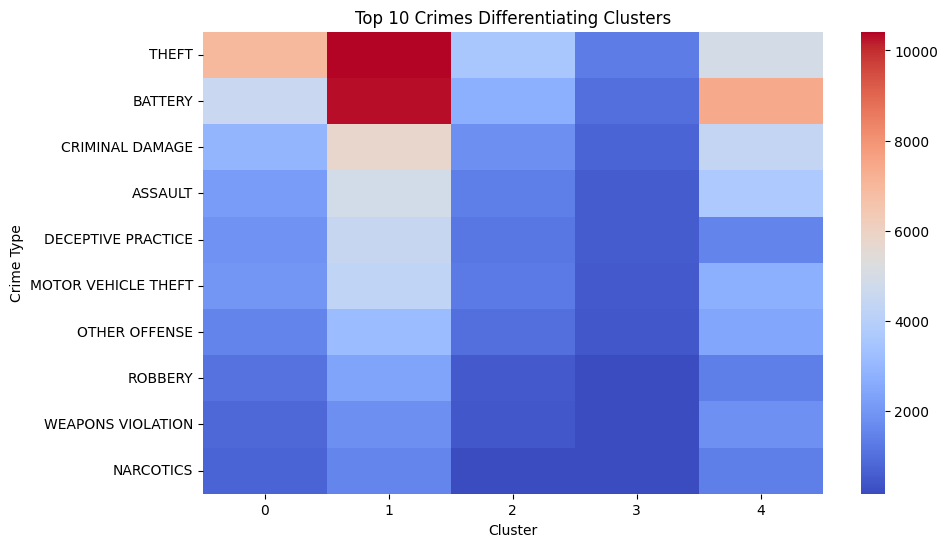

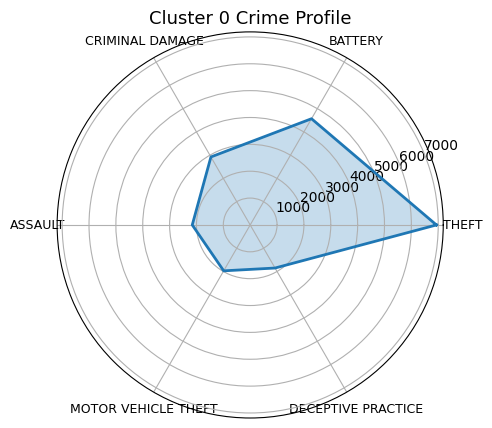

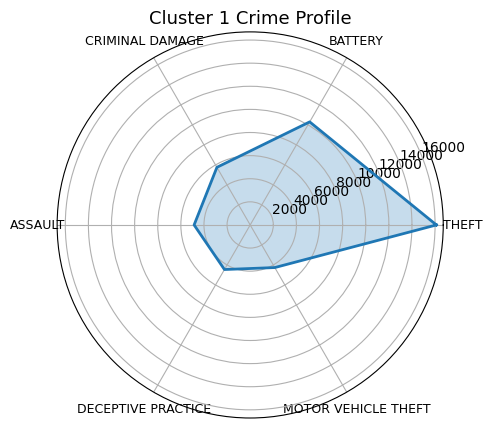

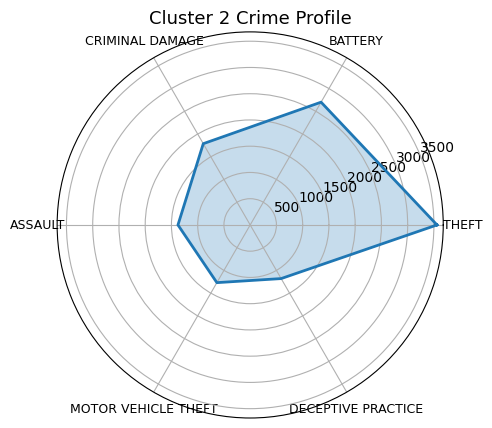

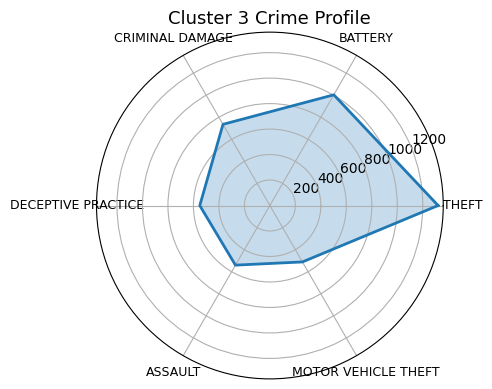

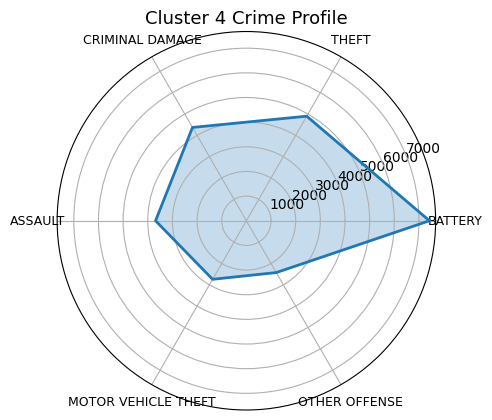

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Pivot table: rows = communities, columns = crime types
crime_matrix = (
    gdf_joined
    .pivot_table(index="community", columns="Primary Type", values="ID", aggfunc="count", fill_value=0)
)

# Normalize
scaler = StandardScaler()
scaled = scaler.fit_transform(crime_matrix)

# Cluster
kmeans = KMeans(n_clusters=5, random_state=42)
crime_matrix["cluster"] = kmeans.fit_predict(scaled)

# ---- Cluster composition summary ----
print("\n=== Cluster Size Summary ===")
print(crime_matrix["cluster"].value_counts().sort_index())

# ---- Top crimes per cluster ----
print("\n=== Top Crime Types per Cluster ===")
for c in sorted(crime_matrix["cluster"].unique()):
    cluster_mean = (
        crime_matrix[crime_matrix["cluster"] == c]
        .drop(columns="cluster")
        .mean()
        .sort_values(ascending=False)
    )
    top_crimes = cluster_mean.head(5)

    print(f"\nCluster {c}:")
    for crime, avg_count in top_crimes.items():
        print(f"  • {crime:<25} {avg_count:.2f}")

# ---- Visualize clusters (heatmap) ----
# Crimes with the highest variance across clusters
crime_var = crime_matrix.groupby("cluster").mean().var().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10,6))
sns.heatmap(crime_matrix.groupby("cluster").mean()[crime_var].T, cmap="coolwarm", robust=True)
plt.title("Top 10 Crimes Differentiating Clusters")
plt.xlabel("Cluster")
plt.ylabel("Crime Type")
plt.show()


# ----  Radar chart for each cluster ----
# (Good for showing relative crime profiles)
import matplotlib.pyplot as plt
from math import pi

cluster_profiles = crime_matrix.groupby("cluster").mean()

for c in cluster_profiles.index:
    profile = cluster_profiles.loc[c]
    top_features = profile.sort_values(ascending=False).head(6)
    N = len(top_features)

    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    top_values = top_features.values.tolist()
    top_values += top_values[:1]
    angles += angles[:1]

    plt.figure(figsize=(5,5))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, top_values, linewidth=2)
    ax.fill(angles, top_values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(top_features.index, fontsize=9)
    plt.title(f"Cluster {c} Crime Profile", size=13)
    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipython-input-1300966438.py:37: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


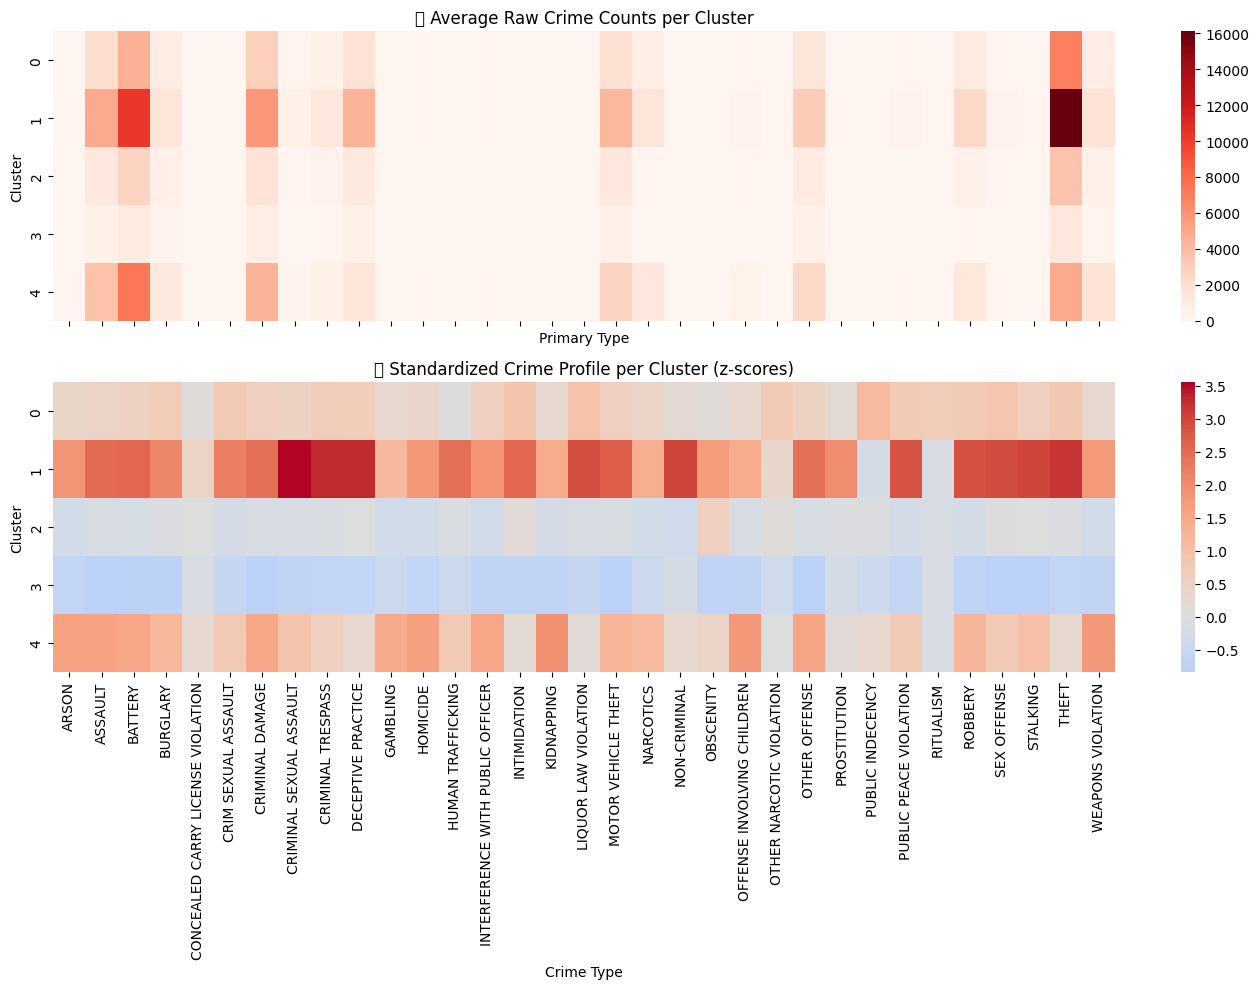

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- 1. Prepare matrix ---
crime_matrix_raw = (
    gdf_joined
    .pivot_table(index="community", columns="Primary Type", values="ID", aggfunc="count", fill_value=0)
)

# --- 2. Scale and cluster ---
scaled = StandardScaler().fit_transform(crime_matrix_raw)
kmeans = KMeans(n_clusters=5, random_state=42)
crime_matrix_raw["cluster"] = kmeans.fit_predict(scaled)

# --- 3. Compute cluster averages ---
cluster_means_raw = crime_matrix_raw.groupby("cluster").mean()
cluster_means_std = pd.DataFrame(scaled, index=crime_matrix_raw.index,
                                 columns=crime_matrix_raw.columns[:-1]) \
                     .assign(cluster=crime_matrix_raw["cluster"]) \
                     .groupby("cluster").mean()

# --- 4. Plot side-by-side ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sns.heatmap(cluster_means_raw, cmap="Reds", ax=axes[0])
axes[0].set_title("🔴 Average Raw Crime Counts per Cluster")
axes[0].set_ylabel("Cluster")

sns.heatmap(cluster_means_std, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("🔵 Standardized Crime Profile per Cluster (z-scores)")
axes[1].set_xlabel("Crime Type")
axes[1].set_ylabel("Cluster")

plt.tight_layout()
plt.show()


In [ ]:
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

clustered = communities.merge(crime_matrix["cluster"], on="community")

# Drop or convert non-serializable columns
# (Keep only columns you actually need for the map)
clustered_clean = clustered.drop(columns=[col for col in clustered.columns if pd.api.types.is_datetime64_any_dtype(clustered[col])])

# Define your desired order
cluster_order = [3, 2, 0, 4, 1]

# Get evenly spaced colors from the "coolwarm" colormap
cmap = plt.cm.get_cmap("coolwarm", len(cluster_order))
colors = [mcolors.to_hex(cmap(i)) for i in range(len(cluster_order))]

# Assign each cluster to its corresponding color
cluster_colors = dict(zip(cluster_order, colors))

# Check color mapping visually (optional)
print(cluster_colors)

# Create map
m = folium.Map(location=[41.8781, -87.6298], zoom_start=10, tiles="cartodbpositron")

# Add polygons with your custom color order
folium.GeoJson(
    clustered_clean,
    style_function=lambda feature: {
        "fillColor": cluster_colors.get(feature["properties"]["cluster"], "gray"),
        "color": "black",
        "weight": 0.3,
        "fillOpacity": 0.6,
    },
    tooltip=folium.GeoJsonTooltip(fields=["community", "cluster"]),
).add_to(m)

# --- Add a simple color legend ---
legend_html = """
<div style="
    position: fixed;
    bottom: 30px; left: 30px; width: 180px;
    background-color: white;
    border:2px solid grey;
    border-radius:8px;
    padding: 10px;
    z-index:9999;
    font-size:14px;
">
<b>Cluster Colors</b><br>
"""
for c in cluster_order:
    legend_html += f'<i style="background:{cluster_colors[c]};width:18px;height:18px;float:left;margin-right:8px;"></i>Cluster {c}<br>'
legend_html += "</div>"

m.get_root().html.add_child(folium.Element(legend_html))

m

/tmp/ipython-input-2663015160.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("coolwarm", len(cluster_order))


{3: '#3b4cc0', 2: '#8db0fe', 0: '#dddddd', 4: '#f49a7b', 1: '#b40426'}


# Insights
This spatial analysis of the city of Chicago has revealed some interesting key points that should be taken into consideration when building the action plan to mitigate crime.

An initial zone analysis shows that there are 3 areas where crime is very prevalent, those zones being:
- Austin
- Near West Side
- Near North Side

All 3 with alarming crime rates that surpass the 10000 violations per year.

A subsequent analysis was made to determine the top zones for the 5 more prevalent crimes on the city, and surprisingly, Austin came on top for 4 of them (Criminal Damage, Battery, Assault and Motor Vehicle Theft); Additionally, South Shore came up in second place for 3 of the 5 top crimes (Battery, Assault and Criminal Damage), and third place in Motor Vehicle Theft while not being in the top 3 zones with most crimes.

Finally, a clustering exercise was made and 5 different groups were identified. The main factor that determined each cluster was crime rate, however, there were some interesting other characteristics that identified some of the clusters. For example, cluster 4 has a much higher Battery rate than the other middle crime rate cluster (cluster 0), and a much lower Theft rate than cluster 0 as well, which is rare considering that Theft is the most occurring crime in every other cluster.

Another important insight is that the cluster map makes clear that the northern and southern sides of Chicago are mainly comprised of very low crime levels (clusters 2 and 3).

Overall, the recommendation from this spatial analysis is to focus mainly on the areas belonging to cluster 1 while keeping an eye on the potential causes for cluster 4's abnormal Battery rate
